# Foundations of Machine learning

Problem Set 3

Emily Fu

In [ ]:
# importing packages

# train_test_split, GridSearchCV, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# ridge regression, quantile regression, logistic regression
from sklearn.linear_model import Ridge, QuantileRegressor, LogisticRegression
# KNN
from sklearn.neighbors import KNeighborsClassifier
# standard scaler
from sklearn.preprocessing import StandardScaler
# pipeline
from sklearn.pipeline import Pipeline

import numpy as np

import matplotlib.pyplot as plt

# california housing dataset and wine dataset
from sklearn.datasets import fetch_california_housing, load_wine

In [ ]:
# import data and set parameters

# random seed
seed = 420

# number of folds for cross-validation
k_folds = 5

# define possible penalties in ridge regression
param_grid_ridge = {'ridge__alpha': np.logspace(-4, 4, 50)}

# define possible penalties in quantile regression 
# would have used the same as param_grid_ridge but it takes too long
param_grid_qr = {'qr__alpha': np.logspace(-4, 1, 10)}

# define the parameter grid (possible values for n_neighbors)
param_grid = {'n_neighbors': np.arange(1, 25)}

# penalty parameter grid for logistic regression
param_grid_logistic = {'logistic__C': np.logspace(-4, 4, 50)}

# Split the dataset into three parts: a training set (60%) used for initial model fitting, 
# a calibration set (20%) used for conformal inference calibration, 
# and a test set (20%) used for final evaluation.
housing = fetch_california_housing()
wine = load_wine()
X_housing, y_housing = housing['data'], housing['target']
X_wine, y_wine = wine['data'], wine['target']

# training vs test/calibration data
X_housing_train, X_housing_temp, y_housing_train, y_housing_temp = train_test_split(
    X_housing, y_housing, test_size=0.40, random_state=seed, shuffle=True)
X_wine_train, X_wine_temp, y_wine_train, y_wine_temp = train_test_split(
    X_wine, y_wine, test_size=0.40, random_state=seed, shuffle=True)

# calibration data and test data
X_housing_cal, X_housing_test, y_housing_cal, y_housing_test = train_test_split(
    X_housing_temp, y_housing_temp, test_size=0.50, random_state=seed, shuffle=True)
X_wine_cal, X_wine_test, y_wine_cal, y_wine_test = train_test_split(
    X_wine_temp, y_wine_temp, test_size=0.50, random_state=seed, shuffle=True)

# subset of points for plotting
subset_indices = np.random.choice(len(X_housing_test), size=20, replace=False)

# store size of calibration set
n_housing_cal = len(X_housing_cal)
n_wine_cal = len(X_wine_cal)

# confidence interval
alpha = 0.1

# quantiles for quantile regression
quantile_05 = alpha / 2
quantile_95 = 1 - alpha / 2

# significance level
sig_housing = (1 - alpha) * (n_housing_cal + 1) / n_housing_cal
sig_wine = (1 - alpha) * (n_wine_cal + 1) / n_wine_cal

## Continuous Outcome Regression

Implement conformal inference for regression using ridge regression with penalty parameter selected via cross-validation as the model, and the conformity score: $s(X,y) = |y−\hat{f}(X)|$ where $\hat{f}(X)$ is the predicted value from the ridge regression model. 

Empirical coverage on the test set: 0.887
Average interval width: 2.090


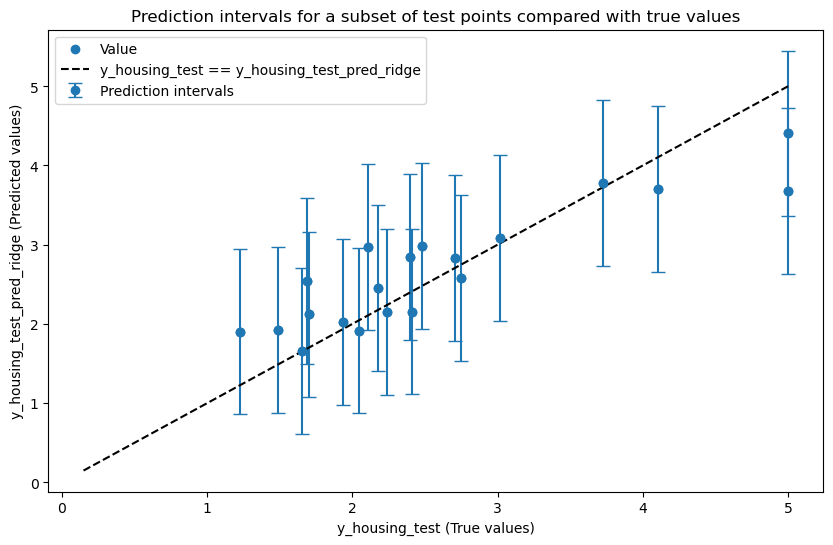

In [ ]:
# scaling features and ridge regression with grid search
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())])
# grid search with 5-fold cross-validation
grid_ridge = GridSearchCV(estimator=pipe_ridge, param_grid=param_grid_ridge, cv=k_folds)

# Train your penalized linear regression model on the training set using the optimal penalty_housing found using cross-validation.
grid_ridge.fit(X_housing_train, y_housing_train)

# For each point (X_i,y_i) in the calibration set, compute the conformity_housing score s(X_i,y_i).
best_model_ridge = grid_ridge.best_estimator_
y_housing_cal_pred_ridge = best_model_ridge.predict(X_housing_cal)
conformity_housing_scores_ridge = np.abs(y_housing_cal - y_housing_cal_pred_ridge)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n+ 1)/n-th quantile of the calibration scores, where n is the size of the calibration set.
quantile_ridge = np.quantile(conformity_housing_scores_ridge, sig_housing)

# For evaluation, construct prediction intervals [\hat{f}(X) - q, \hat{f}(X) + q] 
# where q is the appropriate quantile of calibration scores.
y_housing_test_pred_ridge = best_model_ridge.predict(X_housing_test)
lower_ridge = y_housing_test_pred_ridge - quantile_ridge
upper_ridge = y_housing_test_pred_ridge + quantile_ridge

# Compute empirical coverage on the test set, 
# when the true value falls within the prediction set
coverage_ridge = np.mean((y_housing_test >= lower_ridge) & (y_housing_test <= upper_ridge))
print(f'Empirical coverage on the test set: {coverage_ridge:.3f}')

# calculate average interval width, 
interval_widths_ridge = upper_ridge - lower_ridge
avg_interval_width_ridge = np.mean(interval_widths_ridge)
print(f'Average interval width: {avg_interval_width_ridge:.3f}')

# and plot prediction intervals for a subset of test points compared with true values.
plt.figure(figsize=(10, 6))
plt.scatter(y_housing_test[subset_indices], y_housing_test_pred_ridge[subset_indices], label='Value')
plt.errorbar(y_housing_test[subset_indices], y_housing_test_pred_ridge[subset_indices], 
             yerr=[y_housing_test_pred_ridge[subset_indices] - lower_ridge[subset_indices], 
                    upper_ridge[subset_indices] - y_housing_test_pred_ridge[subset_indices]], 
             fmt='o', capsize=5, label='Prediction intervals')
plt.plot([y_housing_test.min(), y_housing_test.max()], [y_housing_test.min(), y_housing_test.max()], 'k--', 
         label='y_housing_test == y_housing_test_pred_ridge')
plt.xlabel('y_housing_test (True values)')
plt.ylabel('y_housing_test_pred_ridge (Predicted values)')
plt.title('Prediction intervals for a subset of test points compared with true values')
plt.legend()
plt.show()

## Quantile Regression

Using the same continuous outcome dataset from the previous problem, implement conformal inference with quantile regression. Fit quantile regression models for quantiles $\tau_{\alpha/2}$ and $\tau_{1−\alpha/2}$ (e.g., 0.05 and 0.95 for $\alpha = 0.1$). Let $t_{\alpha/2}$ and $t_{1−\alpha/2}$ be the predicted quantiles. Use the conformity score: $s(X,y) = \text{max} [t_{\alpha/2}(X) − y, y − t_{1−\alpha/2}(X)]$

In [ ]:
# create quantile regression models for the two quantiles
qr_05 = Pipeline([('scaler', StandardScaler()),
                  ('qr', QuantileRegressor(quantile=quantile_05))])
qr_95 = Pipeline([('scaler', StandardScaler()),
                  ('qr', QuantileRegressor(quantile=quantile_95))])

# grid search with 5-fold cross-validation for both quantiles
grid_qr_05 = GridSearchCV(estimator=qr_05, param_grid=param_grid_qr, cv=k_folds)
grid_qr_95 = GridSearchCV(estimator=qr_95, param_grid=param_grid_qr, cv=k_folds)

# fit the models on the training data
grid_qr_05.fit(X_housing_train, y_housing_train)
grid_qr_95.fit(X_housing_train, y_housing_train)

# For each point (Xi,yi) in the calibration set, compute the conformity score s(Xi,yi).
t_05_cal = grid_qr_05.predict(X_housing_cal)
t_95_cal = grid_qr_95.predict(X_housing_cal)
conformity_housing_scores_qr = np.maximum(t_05_cal - y_housing_cal, y_housing_cal - t_95_cal)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n+ 1)/n-th quantile of the calibration scores, where n is the size of the calibration set.
quantile_qr = np.quantile(conformity_housing_scores_qr, sig_housing)

# For evaluation, construct prediction intervals [\hat{f}(X) - q, \hat{f}(X) + q] 
# where q is the appropriate quantile of calibration scores.
t_05_test = grid_qr_05.predict(X_housing_test)
t_95_test = grid_qr_95.predict(X_housing_test)
lower_qr = t_05_test - quantile_qr
upper_qr = t_95_test + quantile_qr

# Compute empirical coverage on the test set, 
coverage_qr = np.mean((y_housing_test >= lower_qr) & (y_housing_test <= upper_qr))
print(f'Empirical coverage on the test set: {coverage_qr:.3f}')

# calculate average interval width, 
interval_widths_qr = upper_qr - lower_qr
avg_interval_width_qr = np.mean(interval_widths_qr)
print(f'Average interval width: {avg_interval_width_qr:.3f}')

Empirical coverage on the test set: 0.890
Average interval width: 2.208


Like we saw in the lectures, the point prediction score yields confidence band of constant width. The quantile regression 

## Discrete Classification

Fit a penalized logistic regression model using scikit-learn’s LogisticRegression with L1 or L2 regularization. Use cross-validation on the training set to find the optimal penalty parameter λ that minimizes classification error.
ok to be honest i'm having the craziest case of food poisoning ever rn and this problemset is my final straw

Implement conformal inference for the classification problem using the following procedure. Let $j(y,x)$ be the rank of
f(y|x) across all possible labels y, where $\hat{f}(y|x)$ represents the predicted probability of class $y$ given features $x$. Define the conformity score as: $s(x,y) = \sum_{y'} 1(j(y|x) \geq j(y'|x))f(y|x)$, where $1(·)$ is the indicator function

In [ ]:
# logistic regression with penalty
pipe_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l1', solver='liblinear'))])

# grid search with 5-fold cross-validation for logistic regression
grid_logistic = GridSearchCV(estimator=pipe_logistic, param_grid=param_grid_logistic, cv=k_folds)
grid_logistic.fit(X_wine_train, y_wine_train)
best_model_logistic = grid_logistic.best_estimator_

# calculate conformity scores for logistic regression
# For a fixed x, the classifier outputs a probability distribution over possible y
# sort labels by predicted probability
# small rank = very likely label
# large rank = unlikely label
# define s(x,y) as the total probability mass of other y’ that are at least as likely as y

# possible classes of label for each x
classes = best_model_logistic.classes_

# predicted class probabilities in calibration set
probs_cal = best_model_logistic.predict_proba(X_wine_cal)

# order labels by probability (descending)
order_cal = np.argsort(-probs_cal, axis=1)
probs_sorted_cal = np.take_along_axis(probs_cal, order_cal, axis=1)
cumsum_sorted_cal = np.cumsum(probs_sorted_cal, axis=1)

# map true labels to column indices
class_to_col = {c:j for j, c in enumerate(classes)}
# which label is the actual one
true_col_cal = np.array([class_to_col[y] for y in y_wine_cal])

# position of true label in the sorted ranking
pos_cal = np.array([np.where(order_cal[i] == true_col_cal[i])[0][0]
                    for i in range(len(true_col_cal))])

# conformity score for true label (using cumulative probabilities)
scores_cal = cumsum_sorted_cal[np.arange(len(true_col_cal)), pos_cal]

# find the (1−alpha)(n+1)/n-th quantile of the calibration scores
quantile_logistic = np.quantile(scores_cal, sig_wine)

# evaluate on test set
probs_test = best_model_logistic.predict_proba(X_wine_test)   # (n_test, K)
order_test = np.argsort(-probs_test, axis=1)
probs_sorted_test = np.take_along_axis(probs_test, order_test, axis=1)
cumsum_sorted_test = np.cumsum(probs_sorted_test, axis=1)
mask_sorted = cumsum_sorted_test <= quantile_logistic

# map mask back to original class columns
mask = np.zeros_like(mask_sorted, dtype=bool)
for i in range(mask.shape[0]):
    mask[i, order_test[i]] = mask_sorted[i]

# fraction of test points where the true label is in the prediction set
true_col_test = np.array([class_to_col[y] for y in y_wine_test])
coverage = np.mean(mask[np.arange(len(y_wine_test)), true_col_test])
print('Empirical coverage:', coverage)

# mean number of labels in the prediction sets
avg_size = mask.sum(axis=1).mean()
print('Average set size:', avg_size)

# conditional coverage by class
for c in classes:
    idx = (y_wine_test == c)
    cov_c = np.mean(mask[idx, class_to_col[c]])
    print(f'Coverage rate for true class {c}: {cov_c}')

Empirical coverage: 0.9444444444444444
Average set size: 1.1944444444444444
Coverage rate for true class 0: 0.9333333333333333
Coverage rate for true class 1: 1.0
Coverage rate for true class 2: 0.875


## k-Nearest Neighbors Classification

Repeat the conformal inference procedure from the previous problem, but replace the penalized logistic regression with k-nearest neighbors classification. Use cross-validation on the training set to select the optimal number of neighbors k. Use the same conformity score definition as in the previous problem. Compare the coverage and efficiency (average prediction set size) with the logistic regression results.